# Validation 2: Score–affinity correlation

Spearman rank correlation between Rosetta summary scores (`rosetta_best_score`, `rosetta_mean_score`) and experimental log-affinity (IC50, Kd). Reports per-allele and pooled correlations.

Censored values at the assay detection limits are excluded.

Outputs: `correlations_per_allele.csv`, `correlations_pooled.json`, `figure3_score_vs_affinity.{png,pdf}` in `IEDB_validation/02_score_affinity/`.

Reads only `metadata.csv`; does not touch structure files.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
from utils import load_metadata, set_plot_style

set_plot_style()

In [2]:
# === Paths ===
HF_DIR  = Path('/home/huntek1/main_project/data/IEDB_data_clean/huggingface')
OUT_DIR = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/02_score_affinity')
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG3_DIR = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure3_panels')
FIG3_DIR.mkdir(parents=True, exist_ok=True)

# === Column names (adjust to your metadata.csv schema) ===
COL_ALLELE     = 'allele'
COL_FLAGGED    = 'flagged'
COL_BEST_SCORE = 'rosetta_best_score'
COL_MEAN_SCORE = 'rosetta_mean_score'

# IC50 and Kd are in separate columns (one row per peptide–allele pair).
COL_IC50 = 'ic50_value'   # adjust if different
COL_KD   = 'kd_value'     # adjust if different

# Censoring thresholds; values >= these are at the assay detection limit
# and are excluded from correlation analyses.
IC50_CEILINGS = (20000.0, 70000.0)
KD_CEILINGS   = (5000.0, 20000.0)

## Load and filter

In [3]:
df = load_metadata(HF_DIR / 'metadata.csv')
df = df[~df[COL_FLAGGED].astype(bool)].copy()
print(f'Pairs after dropping flagged: {len(df):,}')

Pairs after dropping flagged: 49,473


In [4]:
# === Column schema ===
COL_MEAS_TYPE  = 'measurement_type'
COL_MEAS_VALUE = 'measurement_value'
COL_MEAS_UNITS = 'measurement_units'

# Quick sanity check on units (we assume nM throughout)
unit_counts = df[COL_MEAS_UNITS].value_counts()
print('Measurement units:')
print(unit_counts)
if not (unit_counts.index == 'nM').all():
    print('WARNING: non-nM units present; review before proceeding.')


def is_censored(values: pd.Series, ceilings: tuple) -> pd.Series:
    """A measurement is censored if it equals any of the assay detection limits
    or sits at or above the highest. Censored values are excluded because they
    don't represent quantitative affinities."""
    return values.isin(ceilings) | (values >= max(ceilings))


# Split into IC50 and Kd subsets
ic50 = df[df[COL_MEAS_TYPE] == 'IC50'][
    [COL_ALLELE, COL_BEST_SCORE, COL_MEAN_SCORE, COL_MEAS_VALUE]
].copy()
ic50 = ic50.dropna(subset=[COL_MEAS_VALUE, COL_BEST_SCORE])
ic50 = ic50[~is_censored(ic50[COL_MEAS_VALUE], IC50_CEILINGS)]
ic50['log_value']     = np.log10(ic50[COL_MEAS_VALUE])
ic50['affinity_type'] = 'IC50'

kd = df[df[COL_MEAS_TYPE] == 'Kd'][
    [COL_ALLELE, COL_BEST_SCORE, COL_MEAN_SCORE, COL_MEAS_VALUE]
].copy()
kd = kd.dropna(subset=[COL_MEAS_VALUE, COL_BEST_SCORE])
kd = kd[~is_censored(kd[COL_MEAS_VALUE], KD_CEILINGS)]
kd['log_value']     = np.log10(kd[COL_MEAS_VALUE])
kd['affinity_type'] = 'Kd'

print(f'\nUsable IC50 pairs: {len(ic50):,}  (of 13,629 IC50 rows; {len(ic50)/13629*100:.0f}% retained)')
print(f'Usable Kd pairs:   {len(kd):,}  (of 35,859 Kd rows;   {len(kd)/35859*100:.0f}% retained)')

print('\nIC50 value distribution (post-filter):')
print(ic50[COL_MEAS_VALUE].describe())
print('\nKd value distribution (post-filter):')
print(kd[COL_MEAS_VALUE].describe())

Measurement units:
measurement_units
nM    49473
Name: count, dtype: int64

Usable IC50 pairs: 10,971  (of 13,629 IC50 rows; 80% retained)
Usable Kd pairs:   9,569  (of 35,859 Kd rows;   27% retained)

IC50 value distribution (post-filter):
count    10971.000000
mean      9592.027458
std      16182.876500
min          0.001700
25%        100.000000
50%       1292.000000
75%      11125.950000
max      69924.810000
Name: measurement_value, dtype: float64

Kd value distribution (post-filter):
count     9569.000000
mean      1365.305720
std       2939.997664
min          0.100000
25%         23.300000
50%        164.600000
75%       1120.700000
max      19990.000000
Name: measurement_value, dtype: float64


## Pooled correlations

In [5]:
def spearman(x: np.ndarray, y: np.ndarray) -> dict:
    r = stats.spearmanr(x, y)
    return {'rho': float(r.statistic), 'pvalue': float(r.pvalue), 'n': int(len(x))}

pooled = {
    'IC50': {
        'best_score_vs_log_ic50': spearman(ic50[COL_BEST_SCORE], ic50['log_value']),
        'mean_score_vs_log_ic50': spearman(ic50[COL_MEAN_SCORE], ic50['log_value']),
    },
    'Kd': {
        'best_score_vs_log_kd':   spearman(kd[COL_BEST_SCORE], kd['log_value']),
        'mean_score_vs_log_kd':   spearman(kd[COL_MEAN_SCORE], kd['log_value']),
    },
}

with open(OUT_DIR / 'correlations_pooled.json', 'w') as f:
    json.dump(pooled, f, indent=2)

print(json.dumps(pooled, indent=2))

{
  "IC50": {
    "best_score_vs_log_ic50": {
      "rho": 0.026241774977622874,
      "pvalue": 0.0059815632931341884,
      "n": 10971
    },
    "mean_score_vs_log_ic50": {
      "rho": 0.008834757669550148,
      "pvalue": 0.3548163333217058,
      "n": 10971
    }
  },
  "Kd": {
    "best_score_vs_log_kd": {
      "rho": 0.06623978724058031,
      "pvalue": 8.818194027969189e-11,
      "n": 9569
    },
    "mean_score_vs_log_kd": {
      "rho": 0.043545487729517766,
      "pvalue": 2.033873302129372e-05,
      "n": 9569
    }
  }
}


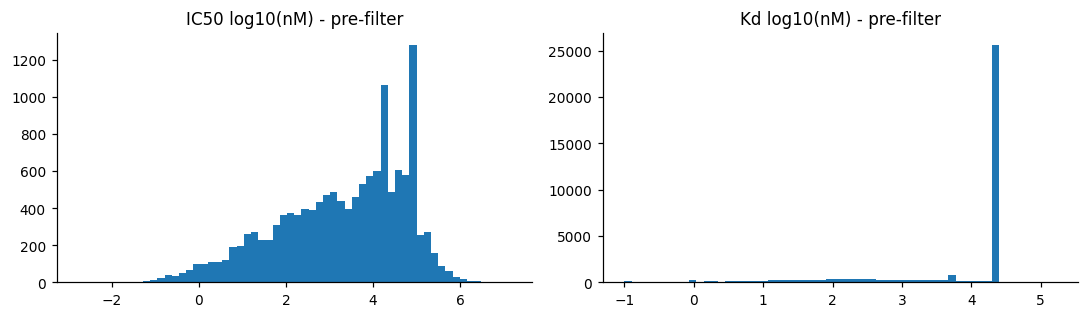

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(np.log10(df[df[COL_MEAS_TYPE]=='IC50'][COL_MEAS_VALUE].dropna()), bins=60)
axes[0].set_title('IC50 log10(nM) - pre-filter')
axes[1].hist(np.log10(df[df[COL_MEAS_TYPE]=='Kd'][COL_MEAS_VALUE].dropna()), bins=60)
axes[1].set_title('Kd log10(nM) - pre-filter')
plt.tight_layout()
plt.show()

## Per-allele correlations

In [7]:
def per_allele_corr(d: pd.DataFrame, score_col: str, label: str) -> pd.DataFrame:
    rows = []
    for allele, g in d.groupby(COL_ALLELE):
        if len(g) < 10:
            continue
        s = spearman(g[score_col], g['log_value'])
        rows.append({'allele': allele, 'metric': label, **s})
    return pd.DataFrame(rows)

per_allele = pd.concat(
    [
        per_allele_corr(ic50, COL_BEST_SCORE, 'best_score_vs_log_ic50'),
        per_allele_corr(ic50, COL_MEAN_SCORE, 'mean_score_vs_log_ic50'),
        per_allele_corr(kd,   COL_BEST_SCORE, 'best_score_vs_log_kd'),
        per_allele_corr(kd,   COL_MEAN_SCORE, 'mean_score_vs_log_kd'),
    ],
    ignore_index=True,
)
per_allele.to_csv(OUT_DIR / 'correlations_per_allele.csv', index=False)
per_allele.head(10)

,allele,metric,rho,pvalue,n
0,A*01:01,best_score_vs_log_ic50,0.185725,9.154290e-03,196
1,A*02:01,best_score_vs_log_ic50,0.080616,4.478050e-09,5279
2,A*03:01,best_score_vs_log_ic50,0.022007,6.509776e-01,425
3,A*11:01,best_score_vs_log_ic50,0.065884,1.520965e-01,474
4,A*23:01,best_score_vs_log_ic50,0.339083,7.194994e-02,29
5,A*24:02,best_score_vs_log_ic50,0.072622,7.873768e-02,587
6,A*26:01,best_score_vs_log_ic50,0.063725,8.080211e-01,17
7,A*29:02,best_score_vs_log_ic50,-0.087495,5.542944e-01,48
8,A*30:01,best_score_vs_log_ic50,-0.185640,5.635041e-01,12
9,A*30:02,best_score_vs_log_ic50,0.395201,2.777731e-02,31


## Figure 3: Score vs log-affinity (pooled, hex density)

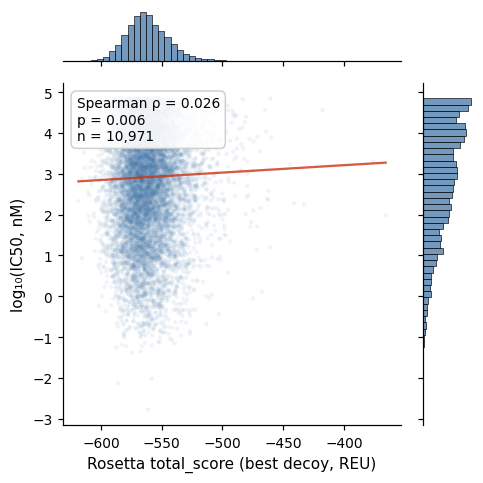

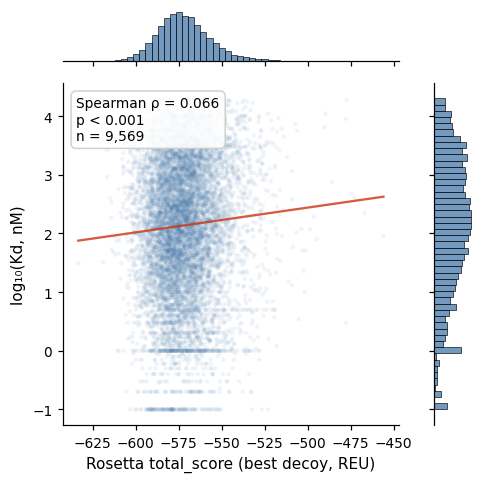

In [8]:
import seaborn as sns

# Compute slopes for annotation
from scipy.stats import linregress
lr_ic50 = linregress(ic50[COL_BEST_SCORE], ic50['log_value'])
lr_kd   = linregress(kd[COL_BEST_SCORE],   kd['log_value'])

def make_joint(data, ylabel, title, slope_intercept, rho_dict, out_name):
    g = sns.jointplot(
        data=data, x=COL_BEST_SCORE, y='log_value',
        kind='scatter',
        height=4.5,
        marginal_kws=dict(bins=50, fill=True, color='#4477AA'),
        joint_kws=dict(alpha=0.08, s=8, color='#4477AA', edgecolor='none'),
    )
    # Trendline
    x = np.linspace(data[COL_BEST_SCORE].min(), data[COL_BEST_SCORE].max(), 100)
    g.ax_joint.plot(x, slope_intercept.slope * x + slope_intercept.intercept,
                    color='#CC3311', linewidth=1.5, alpha=0.8)
    g.ax_joint.set_xlabel('Rosetta total_score (best decoy, REU)')
    g.ax_joint.set_ylabel(ylabel)
    
    # Format p-value separately to avoid nested-quote issues
    if rho_dict['pvalue'] < 0.001:
        p_str = 'p < 0.001'
    else:
        p_str = f"p = {rho_dict['pvalue']:.3f}"

    g.ax_joint.text(
        0.04, 0.96,
        f"Spearman ρ = {rho_dict['rho']:.3f}\n"
        f"{p_str}\n"
        f"n = {rho_dict['n']:,}",
        transform=g.ax_joint.transAxes,
        ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9)
                  )
    #g.figure.suptitle(title, y=1.02)
    g.figure.tight_layout()
    g.figure.savefig(FIG3_DIR / f'{out_name}.png', dpi=300, bbox_inches='tight')
    g.figure.savefig(FIG3_DIR / f'{out_name}.pdf', bbox_inches='tight')
    return g

make_joint(ic50, 'log₁₀(IC50, nM)', 'IC50', lr_ic50,
           pooled['IC50']['best_score_vs_log_ic50'],
           'figure3a_ic50_vs_best_score')
make_joint(kd,   'log₁₀(Kd, nM)',   'Kd',   lr_kd,
           pooled['Kd']['best_score_vs_log_kd'],
           'figure3b_kd_vs_best_score')
plt.show()

In [9]:
print('Pipeline counts:')
print(f'  Total metadata rows:                    {len(df):,}')
print(f'  After dropping flagged:                 (already done above)')

for measurement_type, ceilings in [('IC50', IC50_CEILINGS), ('Kd', KD_CEILINGS)]:
    sub = df[df[COL_MEAS_TYPE] == measurement_type].copy()
    n_total = len(sub)

    # Drop NaN
    sub_nonnan = sub.dropna(subset=[COL_MEAS_VALUE, COL_BEST_SCORE])
    n_after_nan = len(sub_nonnan)

    # Drop censored
    censored = is_censored(sub_nonnan[COL_MEAS_VALUE], ceilings)
    n_censored = int(censored.sum())
    n_after_censor = n_after_nan - n_censored

    print(f'\n  {measurement_type}:')
    print(f'    Pairs of this measurement type:       {n_total:,}')
    print(f'    After dropping NaN score/value:       {n_after_nan:,}   (lost {n_total - n_after_nan:,})')
    print(f'    Of those, censored at detection limit: {n_censored:,}   ({n_censored/n_after_nan*100:.0f}%)')
    print(f'    Usable (kept for correlation):        {n_after_censor:,}   ({n_after_censor/n_total*100:.0f}% of type total)')

Pipeline counts:
  Total metadata rows:                    49,473
  After dropping flagged:                 (already done above)

  IC50:
    Pairs of this measurement type:       13,622
    After dropping NaN score/value:       13,622   (lost 0)
    Of those, censored at detection limit: 2,651   (19%)
    Usable (kept for correlation):        10,971   (81% of type total)

  Kd:
    Pairs of this measurement type:       35,851
    After dropping NaN score/value:       35,851   (lost 0)
    Of those, censored at detection limit: 26,282   (73%)
    Usable (kept for correlation):        9,569   (27% of type total)


In [10]:
# What "round number" values appear suspiciously often? These are likely censoring values.
for measurement_type in ['IC50', 'Kd']:
    sub = df[df[COL_MEAS_TYPE] == measurement_type][COL_MEAS_VALUE]
    counts = sub.value_counts().head(10)
    print(f'\n{measurement_type}: top 10 most common values:')
    print(counts)


IC50: top 10 most common values:
measurement_value
70000.0     730
20000.0     565
100000.0    169
50000.0      70
12.0         52
11.0         49
13.0         47
14.0         44
17.0         40
16.0         37
Name: count, dtype: int64

Kd: top 10 most common values:
measurement_value
20000.0    25571
5000.0       611
1.0          212
0.1          115
2.0           63
5.0           59
0.2           57
3.0           54
10000.0       52
4.0           43
Name: count, dtype: int64


## Per-allele correlation distribution

In [11]:
def summarize_per_allele(d: pd.DataFrame) -> dict:
    return {
        'n_alleles':           len(d),
        'median_rho':          d['rho'].median(),
        'iqr_rho':             (d['rho'].quantile(0.25), d['rho'].quantile(0.75)),
        'n_significant':       int((d['pvalue'] < 0.05).sum()),
        'pct_significant':     (d['pvalue'] < 0.05).mean() * 100,
        'n_rho_above_0.3':     int((d['rho'] > 0.3).sum()),
        'n_negative':          int((d['rho'] < 0).sum()),
    }

summary_rows = []
for label, group in per_allele.groupby('metric'):
    s = summarize_per_allele(group)
    summary_rows.append({'metric': label, **s})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'per_allele_summary.csv', index=False)
print(summary_df.to_string(index=False))

                metric  n_alleles  median_rho                                       iqr_rho  n_significant  pct_significant  n_rho_above_0.3  n_negative
best_score_vs_log_ic50         28    0.076619   (-0.05300282870785895, 0.17164842261379354)              6        21.428571                3           8
  best_score_vs_log_kd         25    0.124960      (0.060822995354988, 0.17577848431908555)             14        56.000000                0           2
mean_score_vs_log_ic50         28   -0.010052   (-0.04775302161042346, 0.10730670190899888)              2         7.142857                0          15
  mean_score_vs_log_kd         25    0.060179 (-0.0016851247456608719, 0.13890539151529213)              8        32.000000                0           7


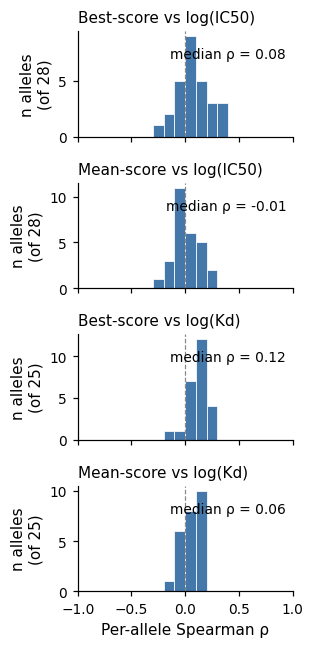

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(3, 6), sharex=True)
metrics = ['best_score_vs_log_ic50', 'mean_score_vs_log_ic50',
           'best_score_vs_log_kd',   'mean_score_vs_log_kd']
titles = ['Best-score vs log(IC50)', 'Mean-score vs log(IC50)',
          'Best-score vs log(Kd)',   'Mean-score vs log(Kd)']

for ax, metric, title in zip(axes, metrics, titles):
    sub = per_allele[per_allele['metric'] == metric]
    ax.hist(sub['rho'], bins=np.arange(-1, 1.05, 0.1), color='#4477AA',
            edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#888888', linewidth=0.8, linestyle='--')
    ax.set_ylabel(f'n alleles\n(of {len(sub)})')
    ax.text(0.97, 0.85,
            f'median ρ = {sub["rho"].median():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)
    ax.set_title(title, fontsize=10, loc='left')

axes[-1].set_xlabel('Per-allele Spearman ρ')
axes[-1].set_xlim(-1, 1)
fig.tight_layout()
fig.savefig(FIG3_DIR / 'figure3b_per_allele_correlations.png', dpi=300)
fig.savefig(FIG3_DIR / 'figure3b_per_allele_correlations.pdf')
plt.show()

In [13]:
strong_alleles = per_allele[
    (per_allele['metric'] == 'best_score_vs_log_ic50') & (per_allele['rho'] > 0.3)
].sort_values('rho', ascending=False)
print(strong_alleles)

     allele                  metric       rho    pvalue   n
9   A*30:02  best_score_vs_log_ic50  0.395201  0.027777  31
11  A*68:01  best_score_vs_log_ic50  0.353393  0.001127  82
4   A*23:01  best_score_vs_log_ic50  0.339083  0.071950  29


In [14]:
neg_alleles = per_allele[
    (per_allele['metric'] == 'best_score_vs_log_kd') & (per_allele['rho'] < 0)
].sort_values('rho')
print(neg_alleles)

     allele                metric       rho    pvalue    n
73  B*27:05  best_score_vs_log_kd -0.122130  0.011351  429
58  A*03:01  best_score_vs_log_kd -0.000869  0.981637  704
